# Algorithm research

End-to-end example for sweeping the UAV swarm simulator and comparing the
four task-allocator variants:

| Variant | Queue order | Preempts busy drones? |
|---|---|---|
| `FIFO`         | insertion       | no  |
| `FIFO_PRIO`    | by priority     | no  |
| `FIFO_PREEMPT` | by priority     | yes (drones on strictly lower-priority tasks) |
| `COST`         | by priority     | yes (cost-weighted auction, incl. MBS relocation) |

The flow below:
1. Inject the `opp_env` environment into this kernel (once).
2. Run a 2-D parameter sweep (`numDrones` x `numMbs`) once per allocator and
   collect per-task CSVs under `sim_data/<label>/<ALGO>/`.
3. Render aggregate comparison plots per metric, then a priority-stratified
   view to see how each allocator treats high- vs low-priority tasks.


In [1]:
# Auto-reload edited .py modules without restarting the kernel. Without
# this, edits to sweep_runner / sweep_plotter would be ignored until a
# full kernel restart (the stale module stays cached on first import).
%load_ext autoreload
%autoreload 2

# Interactive 3-D plots (rotate / zoom) need the ipympl backend.
# Install once with `pip install ipympl`, then restart the kernel for
# this magic to bind. Drop the `widget` line to fall back to inline.
# %matplotlib widget

# Inject the opp_env (omnetpp + inet) environment into this kernel so the
# simulator binary launched by run_sweep finds INET_ROOT, the right Qt
# plugins, etc. Cached in .opp_env_vars.json; pass force=True to refresh.
from sweep_runner import setup_environment
setup_environment()


opp_env loaded from cache (.opp_env_vars.json):
  INET_ROOT=/home/opp_env/default_workspace/inet-4.5.4
  OMNETPP_ROOT=/home/opp_env/default_workspace/omnetpp-6.3.0
  OMNETPP_VERSION=6.3.0
  OMNETPP_RELEASE=omnetpp-6.3.0
  OMNETPP_IMAGE_PATH=/home/opp_env/default_workspace/omnetpp-6.3.0/images:/home/opp_env/default_wo...
  OPP_ENV_VERSION=0.35.0.251114
  PATH=/home/opp_env/default_workspace/inet-4.5.4/bin:/home/opp_env/default_workspac...
  PYTHONPATH=/home/opp_env/default_workspace/inet-4.5.4/python:/home/opp_env/default_works...
  QT_PLUGIN_PATH=/nix/store/8qs879yx84gng0yljdybwi4fbbgg3dyy-qtbase-6.9.0/lib/qt-6/plugins:/ni...
  BUILD_MODES=release debug


{'INET_ROOT': '/home/opp_env/default_workspace/inet-4.5.4',
 'OMNETPP_ROOT': '/home/opp_env/default_workspace/omnetpp-6.3.0',
 'OMNETPP_VERSION': '6.3.0',
 'OMNETPP_RELEASE': 'omnetpp-6.3.0',
 'OMNETPP_IMAGE_PATH': '/home/opp_env/default_workspace/omnetpp-6.3.0/images:/home/opp_env/default_workspace/inet-4.5.4/images',
 'OPP_ENV_VERSION': '0.35.0.251114',
 'PATH': '/home/opp_env/default_workspace/inet-4.5.4/bin:/home/opp_env/default_workspace/omnetpp-6.3.0/bin:/nix/store/cvm20cv2y6p8rik02wvyzx2w76j5wilc-lndir-1.0.5/bin:/nix/store/czj4c9kniwgnniv5w7rjqr3mkvkcymfz-wayland-scanner-1.23.1-bin/bin:/nix/store/8w718rm43x7z73xhw9d6vh8s4snrq67h-python3-3.12.10/bin:/nix/store/sdqvwr8gc74ms9cgf56yvy409xvl8hsf-gettext-0.22.5/bin:/nix/store/2jc1jmzis19adawjwhl8qhdvh7vlbk0q-patchelf-0.15.0/bin:/nix/store/fmysfy9gl5d59yir4fksi29wz10maljg-clang-wrapper-19.1.7/bin:/nix/store/zmk3gqm6sxgar8b84sz66wbs7kx4v2gi-clang-19.1.7/bin:/nix/store/303islqk386z1w2g1ngvxnkl4glfpgrs-glibc-2.40-66-bin/bin:/nix/store/87

## Example sweep

Below is a usage example

Sweeping over two parameters (can sweep up to 3):
- Number of drones - [10,15,20,25,30]
- Number of MBS - [2,4,6,8,10]

While setting constants (good for setting constants that are different from the default value):
- Task limit - 50
- Task generation - Exponential(5s)
- Priority distribution - 3 classes, weights `"5 2 1"` (≈62 / 25 / 13 % high/mid/low). Set `priority_weights = '""'` for uniform, or e.g. `'"1 2 5"'` to flip the bias toward low-pri tasks.
- Wait deadlines - `'"10 30 120"'` seconds per class (HIGH stale in 10s, LOW patient up to 120s). Queued tasks past their deadline are dropped with outcome `EXPIRED` and count against `drop_rate`. Set `task_deadline_weights = '""'` to disable expirations.
- COST energy weight - `0.5` per metre. Raise it to make the auction prefer the nearest eligible drone more aggressively.
- COST halt-priority weights - `'"1000 100 10"'` for an order-of-magnitude gap between classes. Set to `'""'` to fall back to a linear ramp from the scalar `costHaltPriorityWeight`. Per-class lists must have `priority_levels` entries. Only the COST allocator reads these; the FIFO variants ignore them.

We can choose up to 4 different algorithms for comparison: ["FIFO","FIFO_PRIO","FIFO_PREEMPT","COST"]

Set number of repetitions for each instance (for averaging the data later)


In [2]:
from sweep_runner import run_sweep

drones = list(range(10, 30, 5))
mbs    = list(range(2, 10, 2))

task_limit = 50
task_generation_rate = "exponential(5s)"

# Priority distribution. '""' => uniform; otherwise N weights for N classes
# (leftmost = priority 1 = HIGH). Outer quotes are mandatory for string params.
priority_levels  = 3
priority_weights = '"5 2 1"'   # e.g. '"1 2 5"' for mostly low-pri, '"1 3 1"' middle-peaked

# Per-class queue-wait deadlines (seconds). '""' => no expiry; else N values
# (leftmost = priority 1). HIGH-pri stale fastest, LOW-pri patient. A task
# that waits longer than its deadline is dropped with outcome=EXPIRED and
# counts against drop_rate -- this evens the playing field between FIFO
# (favours low-pri completion) and COST (favours high-pri completion).
task_deadline_weights = '"10 30 120"'  # '""' to disable

# COST-only weights (FIFO variants ignore these).
cost_energy_weight         = 0.5              # per-metre travel cost
cost_halt_priority_weight  = 100.0            # scalar; used when the table is empty
cost_halt_priority_weights = '"500 300 100"'  # '""' => linear ramp; else N weights, one per class

# Which allocators to run. Each appears under sim_data/<label>/<ALGO>/.
algorithms = ["FIFO", "FIFO_PRIO", "FIFO_PREEMPT", "COST"]

sweep_dir = run_sweep(
    sweep_params={
        "*.numDrones": drones,   # full pattern -- not a mainNode.app[0] param
        "*.numMbs":    mbs,
    },
    extra_overrides={
        "taskLimit":               task_limit,
        "taskGenerationInterval":  task_generation_rate,
        "priorityLevels":          priority_levels,
        "priorityWeights":         priority_weights,
        "taskDeadlineWeights":     task_deadline_weights,
        "costEnergyWeight":        cost_energy_weight,
        "costHaltPriorityWeight":  cost_halt_priority_weight,
        "costHaltPriorityWeights": cost_halt_priority_weights,
    },
    repetitions=3,
    algorithm=algorithms,
    label="drones_x_mbs",
)
print("Sweep finished:", sweep_dir)


18:44:41 INFO Sweep 'drones_x_mbs/FIFO' starting -- output dir: /home/opp_env/default_workspace/UavSwarmTA/sim_data/drones_x_mbs/FIFO
18:44:41 INFO Sweep dimensions: {'*.numDrones': [10, 15, 20, 25], '*.numMbs': [2, 4, 6, 8]}
18:44:41 INFO Repetitions per cell: 3
18:44:41 INFO Extra (constant) overrides: {'taskLimit': 50, 'taskGenerationInterval': 'exponential(5s)', 'priorityLevels': 3, 'priorityWeights': '"5 2 1"', 'taskDeadlineWeights': '"10 30 120"', 'costEnergyWeight': 0.5, 'costHaltPriorityWeight': 100.0, 'costHaltPriorityWeights': '"500 300 100"', 'algorithmType': '"FIFO"'}
18:44:41 INFO Total cells: 16 (48 runs)
18:44:41 INFO [cell] numDrones=10 | numMbs=2
18:44:41 INFO   -> run 1/48 (rep=0) starting
18:44:41 INFO      ok (0.15s) -> numDrones=10/numMbs=2/rep0-tasks.csv
18:44:41 INFO   -> run 2/48 (rep=1) starting
18:44:42 INFO      ok (0.15s) -> numDrones=10/numMbs=2/rep1-tasks.csv
18:44:42 INFO   -> run 3/48 (rep=2) starting
18:44:42 INFO      ok (0.14s) -> numDrones=10/numMbs=

## Plotter example

To plot the data generated by the simulation choose desired metrics and run `plot_sweep`
Available metrics:
- completion_rate
- drop_rate &nbsp;— any non-COMPLETED outcome (the union below)
- expired_rate &nbsp;— EXPIRED only (missed `taskDeadlineWeights` SLA)
- preempt_drop_rate &nbsp;— DROPPED only (preemption / MBS relocation / drone failure)
- mean_wait
- mean_turnaround
- total_drops
- n_tasks
- throughput

`drop_rate` ≈ `expired_rate + preempt_drop_rate` (plus any `QUEUED`/`UNFINISHED` leftovers at sim end). Plot the split metrics to see *why* an allocator is leaking tasks — COST tends to favour `preempt_drop_rate`, FIFO variants tend to favour `expired_rate`.


## Priority plotter
All data can also be plotted with respect to task priority as shown below



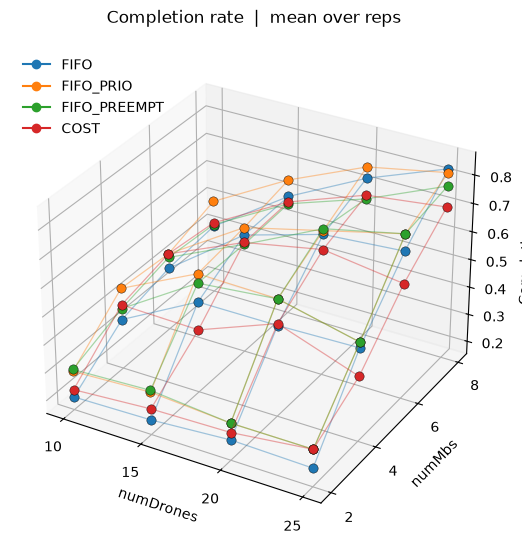

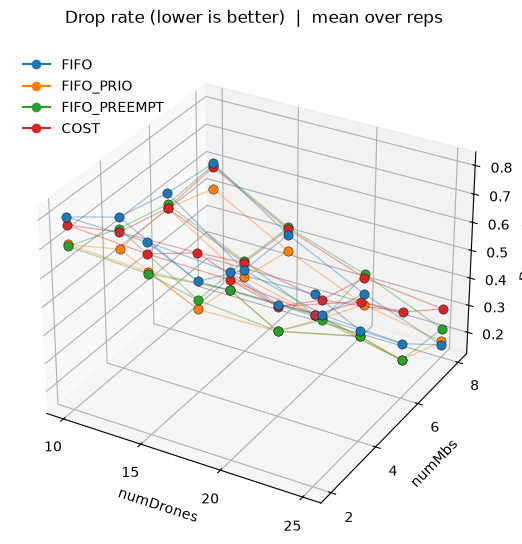

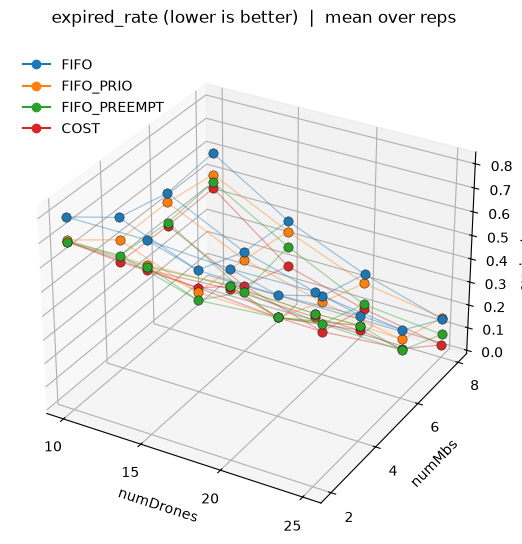

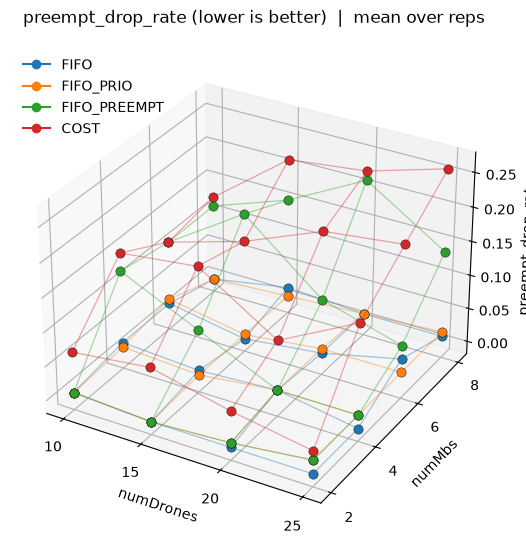

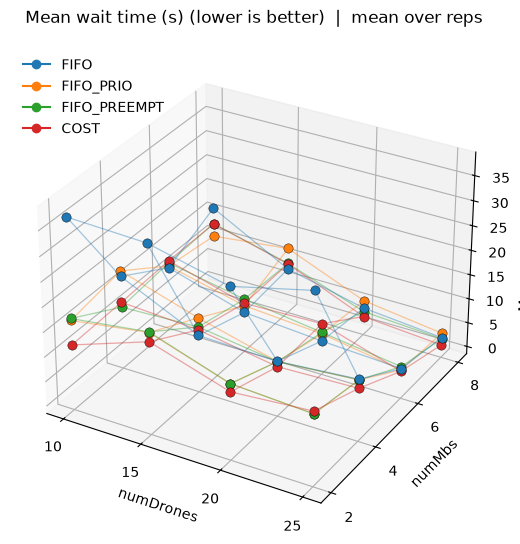

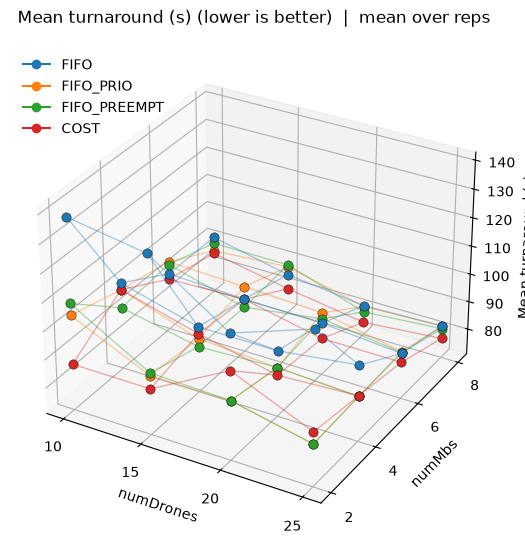

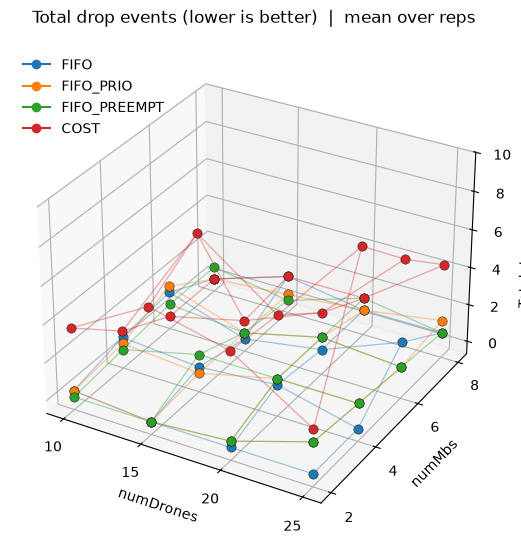

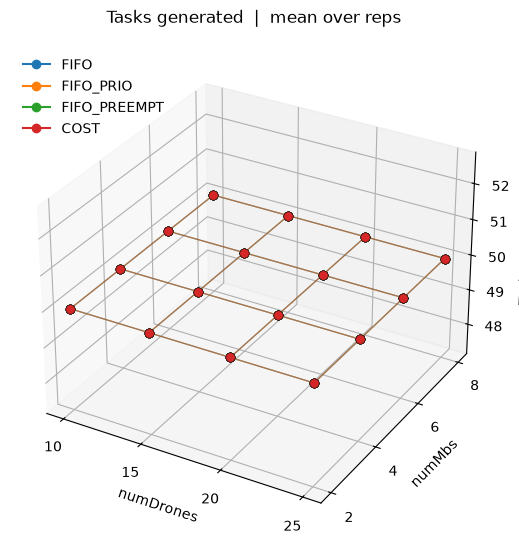

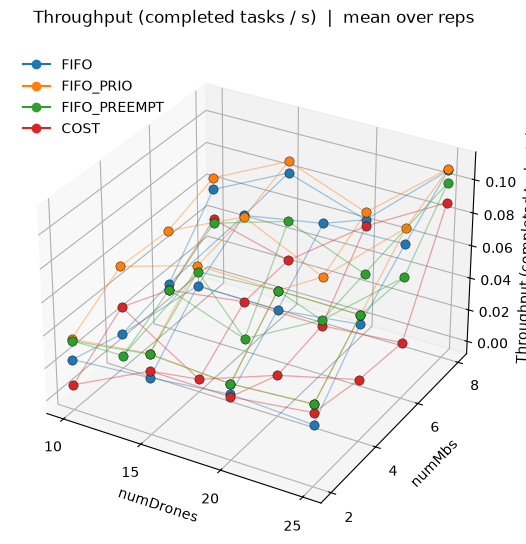

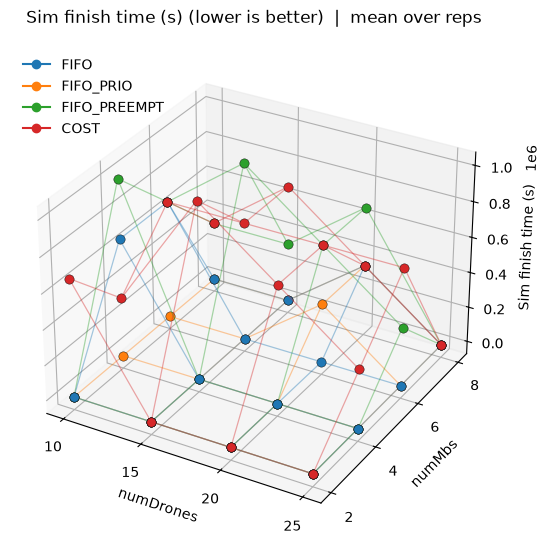

In [3]:
# Aggregate comparison across all allocators in this sweep.
#   metric choices:
#     completion_rate, drop_rate, expired_rate, preempt_drop_rate,
#     mean_wait, mean_turnaround, total_drops, n_tasks, throughput
#   kind="box" (default):
#     2-D sweeps  -> side-by-side boxplots (one panel per algorithm),
#                    showing full per-rep distribution.
#     3-D sweeps  -> heatmap grid (rows = algorithm, cols = values of dim3).
#   kind="line":
#     all algorithms overlaid as mean +/- std lines in the same axes.
#     2-D sweeps  -> one panel per value of dim2, x = dim1.
#     3-D sweeps  -> grid of such panels (rows = dim2, cols = dim3).
# Lower-is-better metrics (drop_rate, expired_rate, preempt_drop_rate,
# mean_wait, mean_turnaround, total_drops) automatically get a reversed
# color scale on 3-D heatmaps.
from sweep_plotter import plot_sweep

plot_kind = "scatter3d"   # "box" for distribution view, "line" for overlay trends, "scatter3d" for 3-D scatter plots

for metric in [
    "completion_rate",
    "drop_rate",
    "expired_rate",       # EXPIRED only -- queue-wait SLA misses
    "preempt_drop_rate",  # DROPPED only -- preemption / MBS reloc / failure
    "mean_wait",
    "mean_turnaround",
    "total_drops",
    "n_tasks",
    "throughput",
    "sim_finish_time"
]:
    fig, df = plot_sweep(sweep_dir, metric=metric, kind=plot_kind)



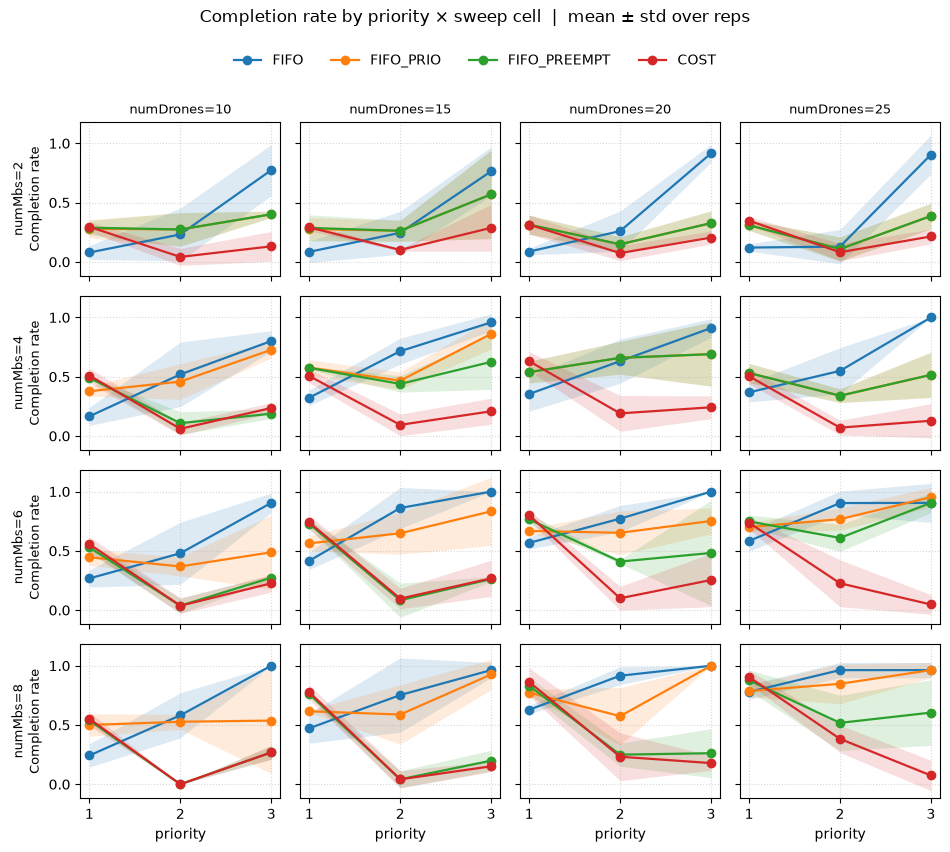

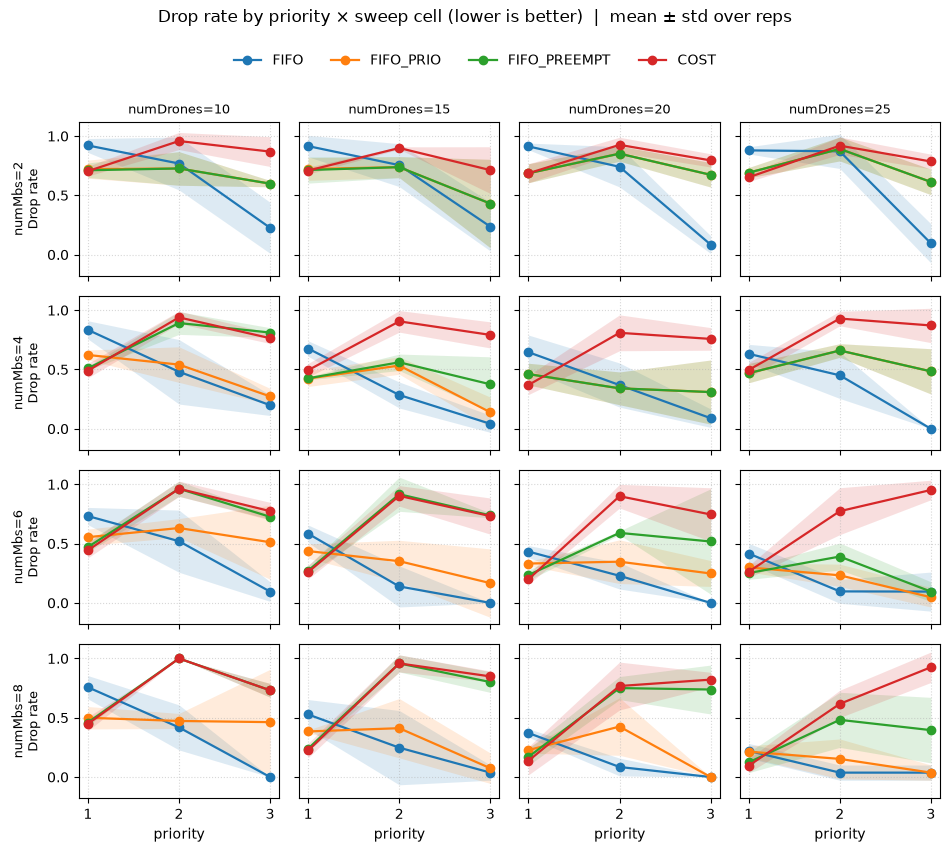

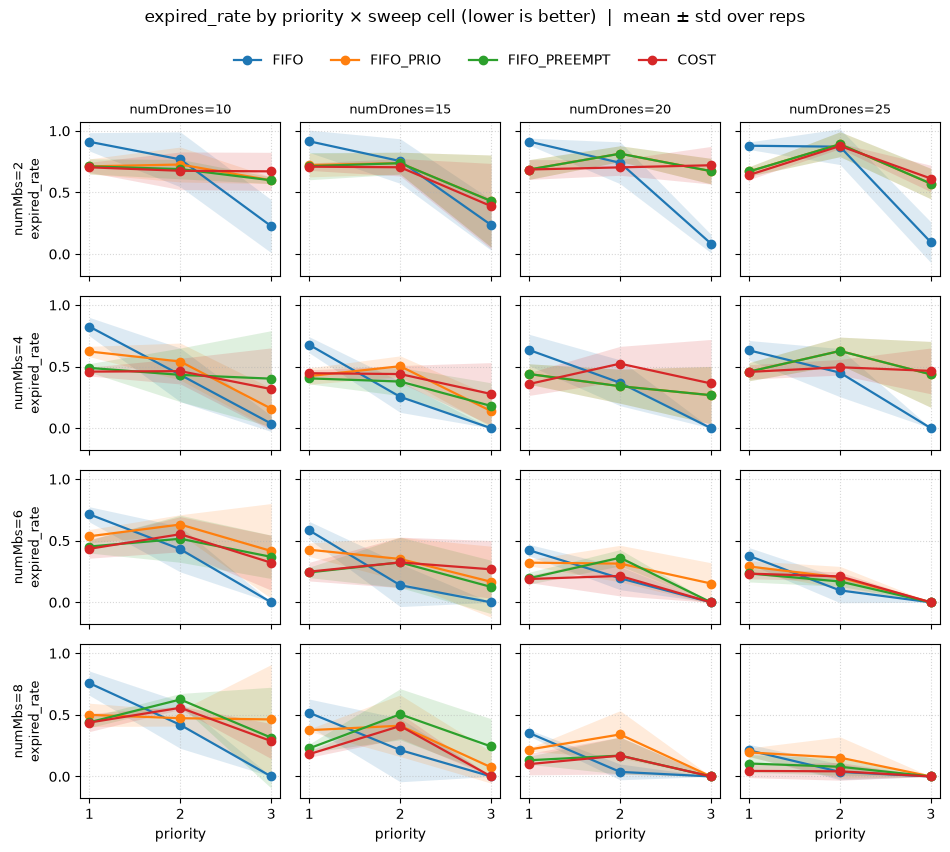

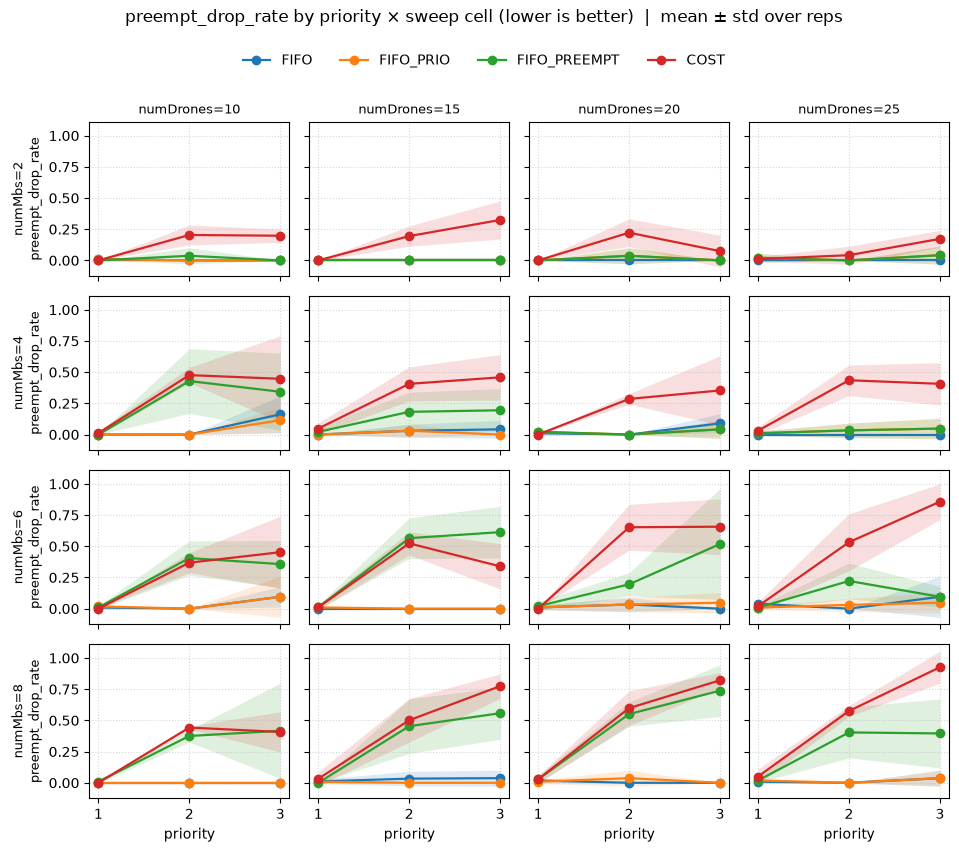

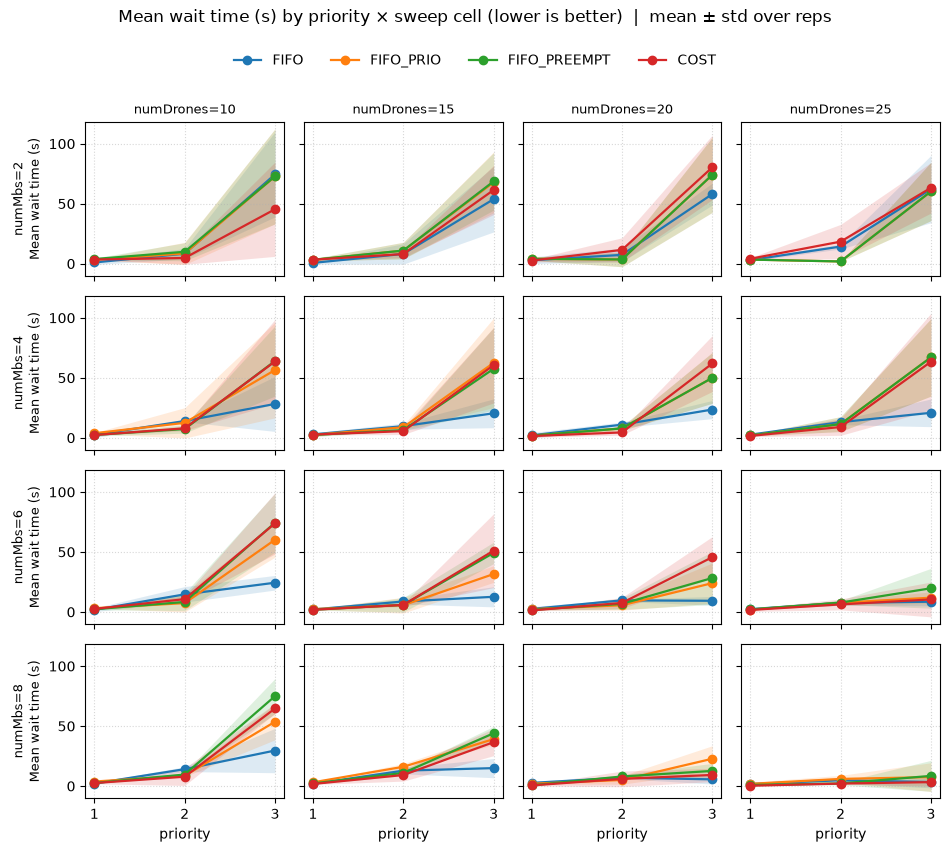

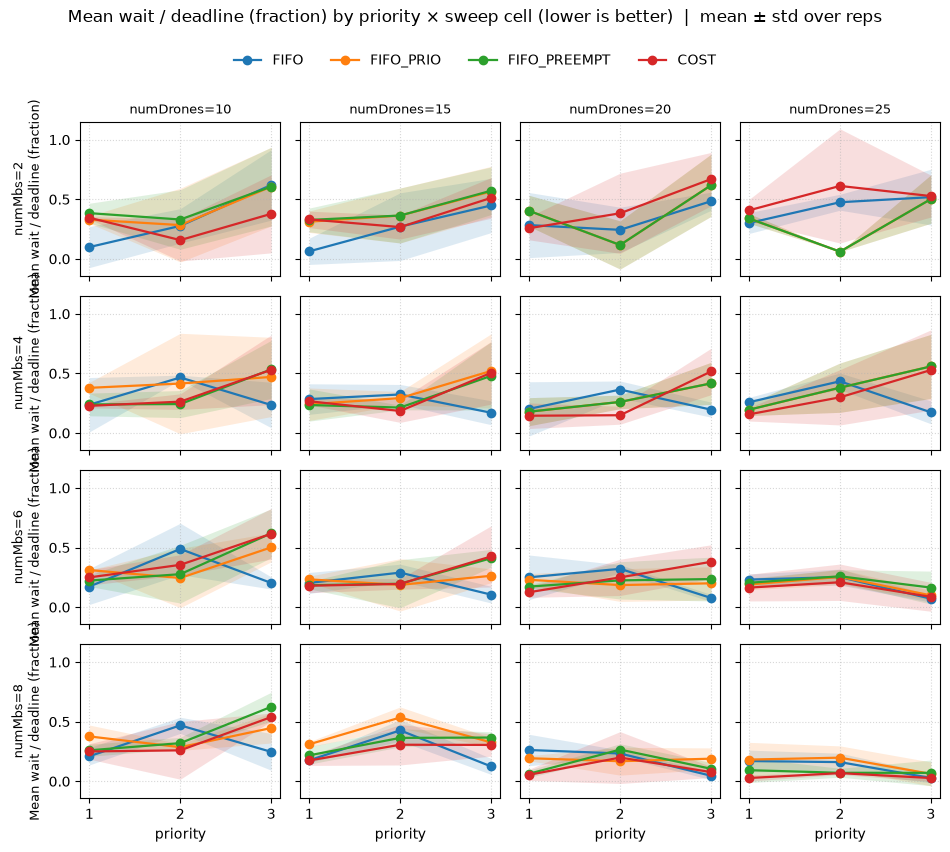

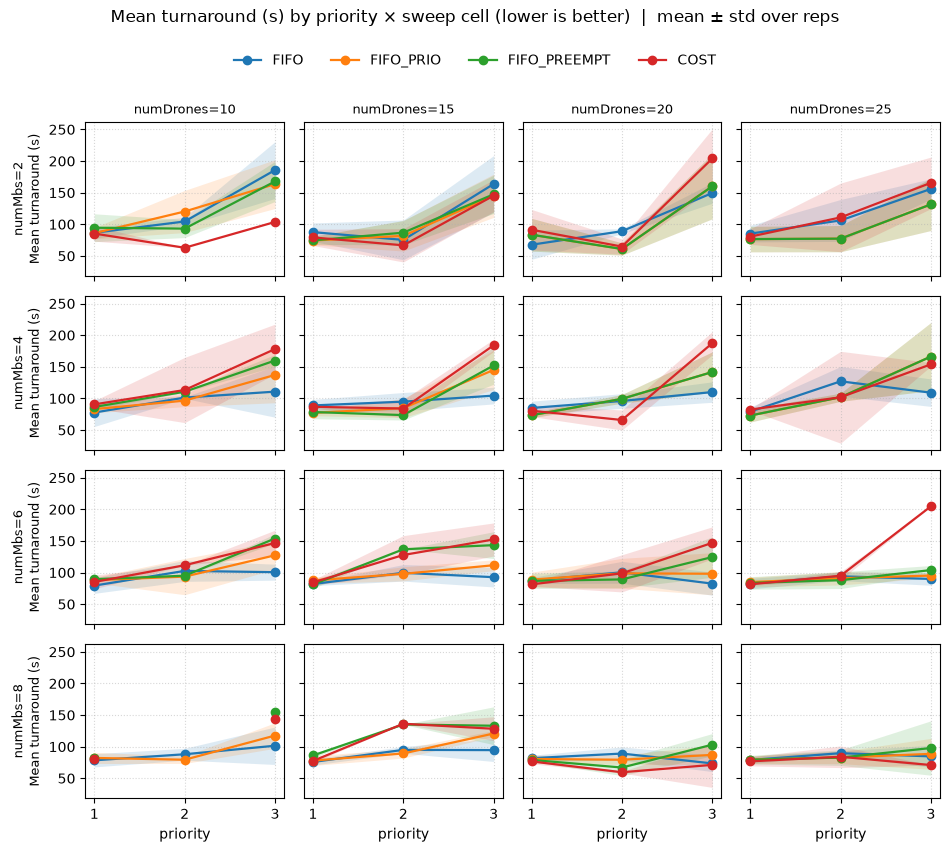

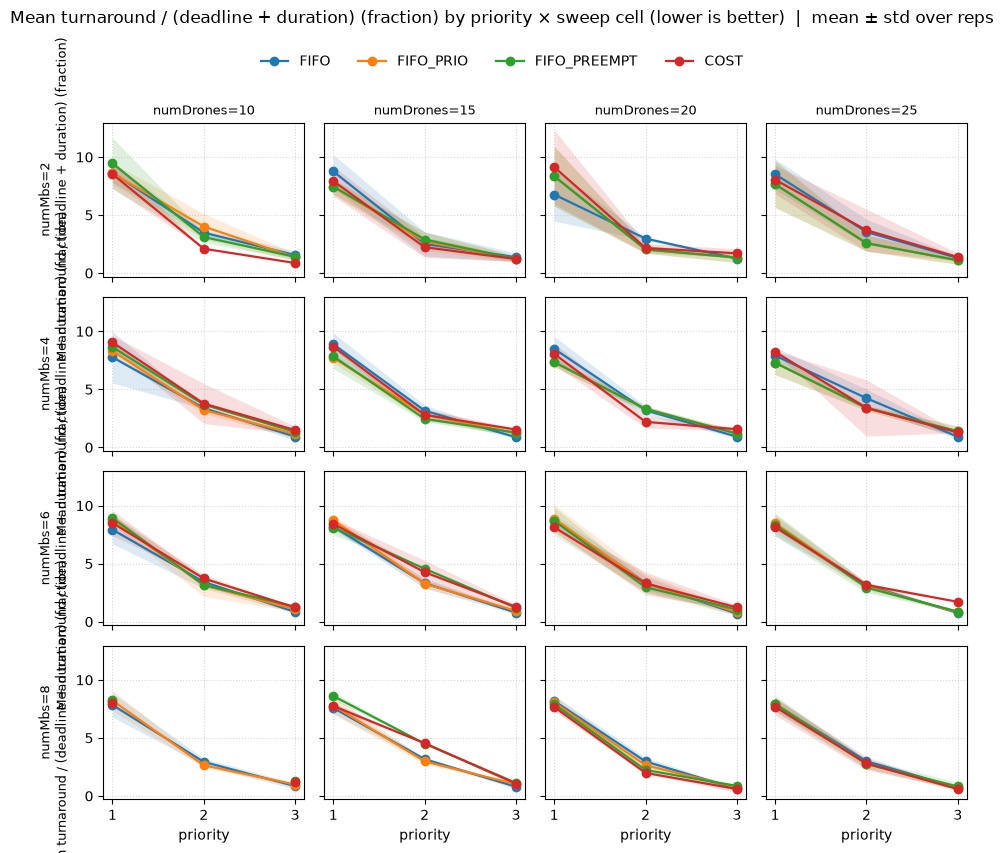

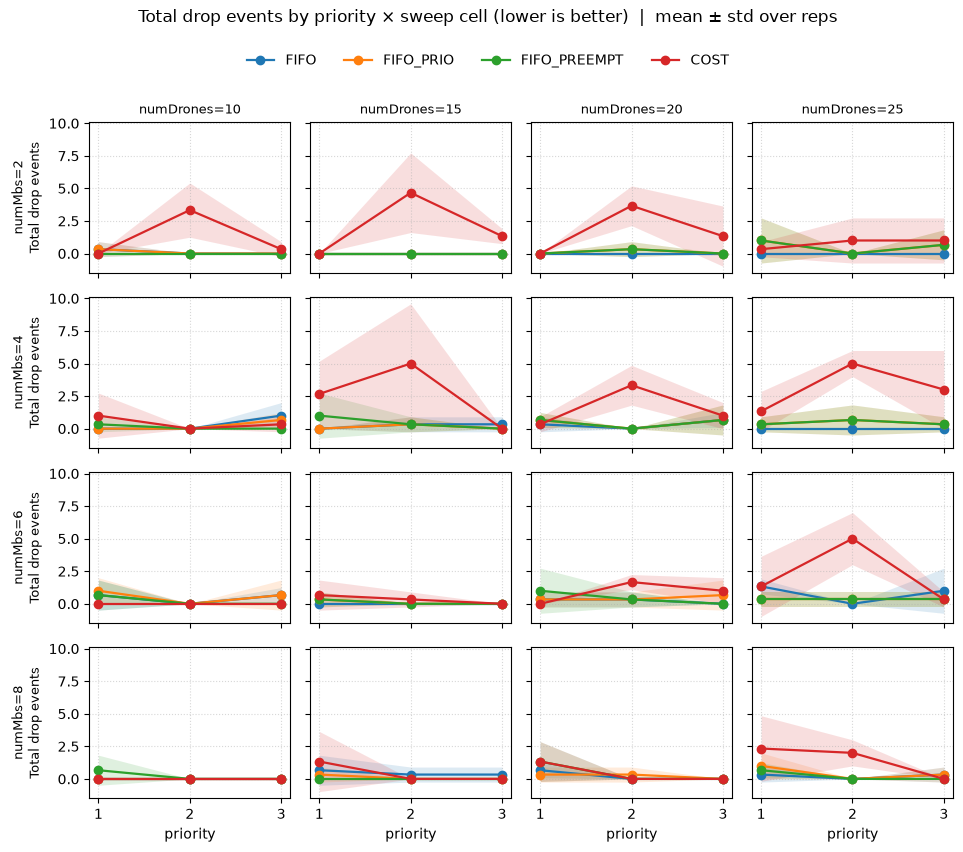

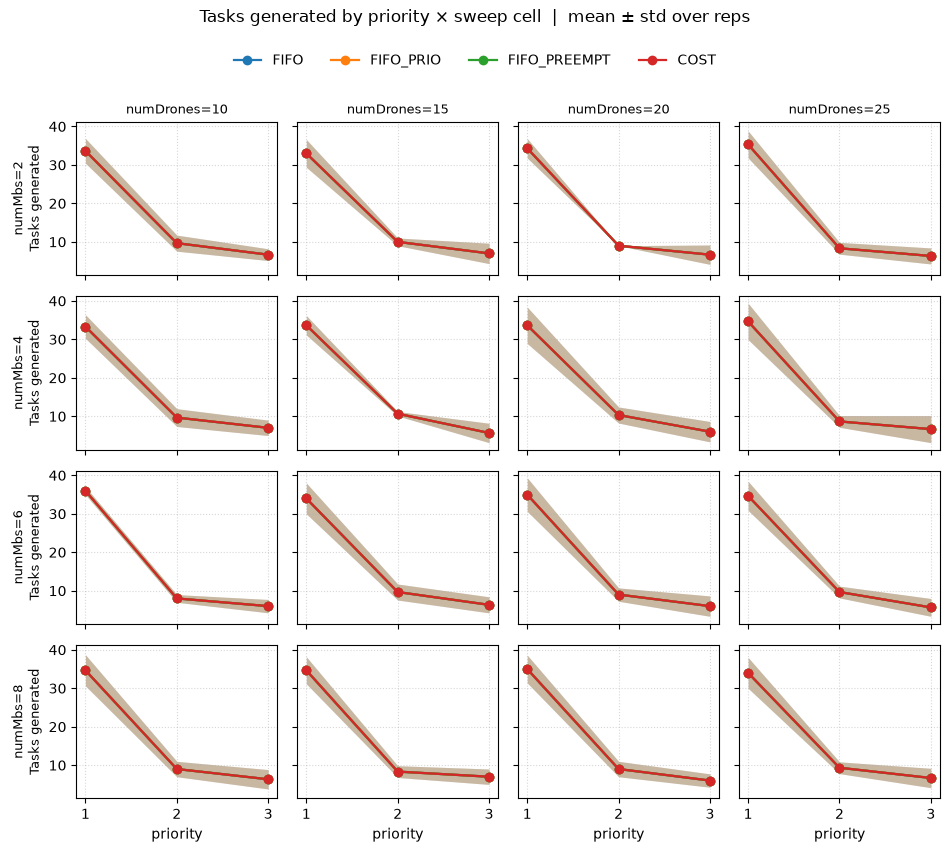

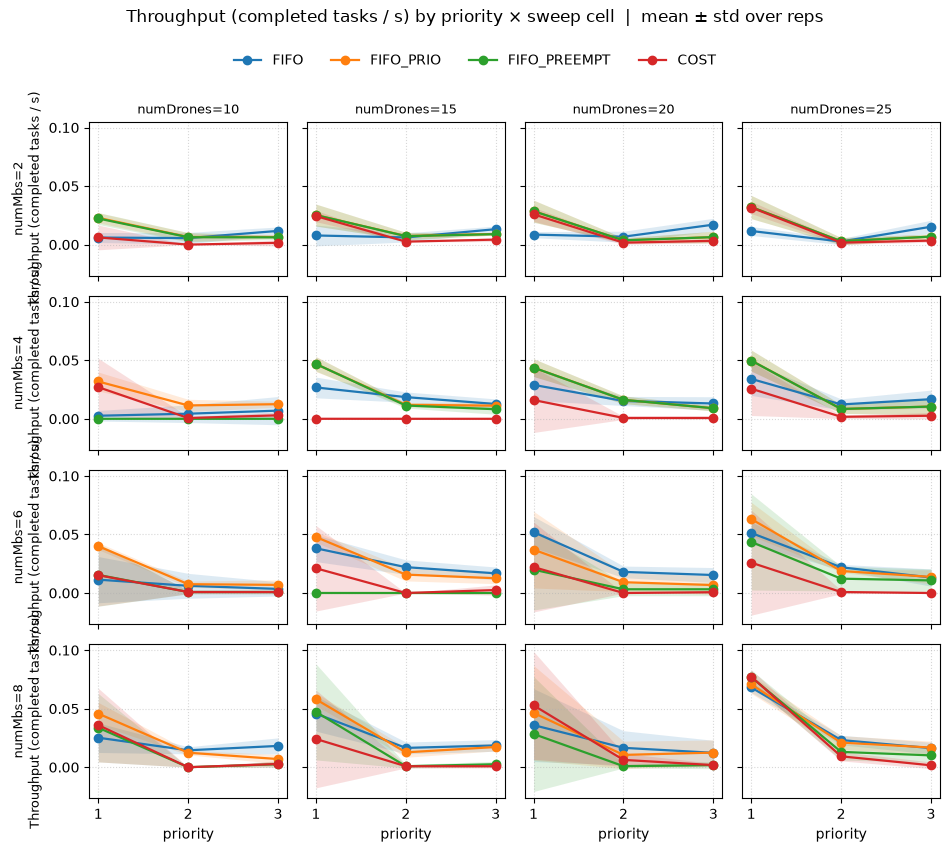

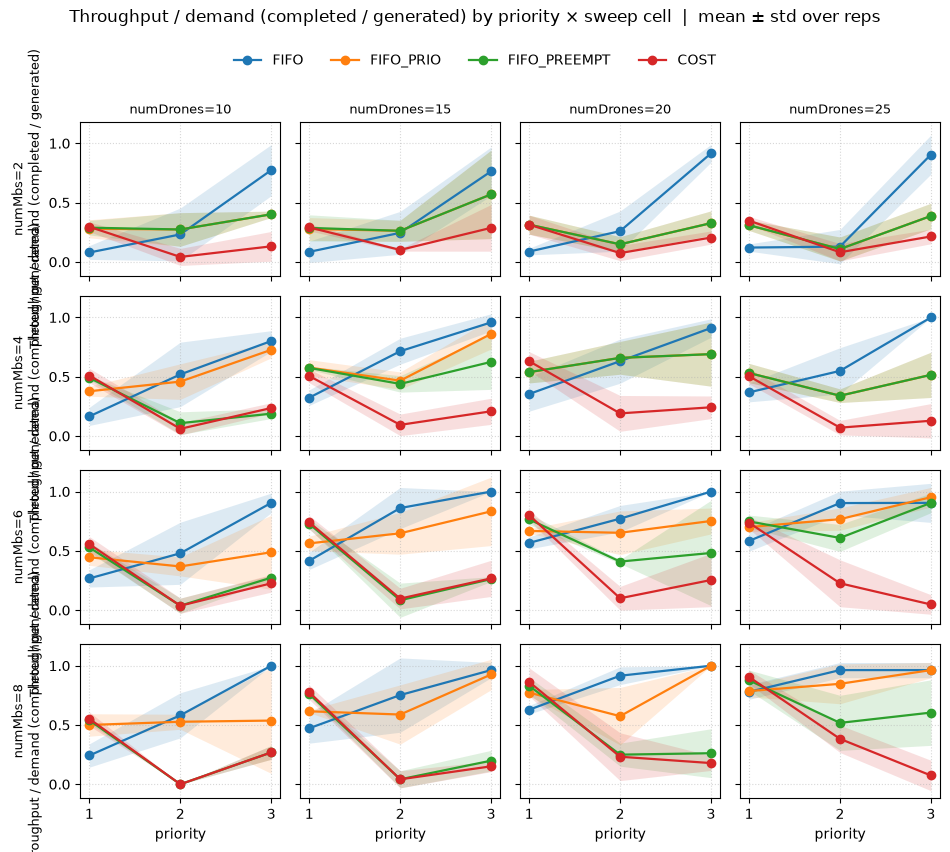

In [4]:
# Priority-aware comparison broken out by sweep cell. Two kinds available:
#
#   kind="grid" (default): one panel per sweep cell, x = priority,
#       one line per algorithm (mean +/- std over reps). Layout for a 2-D
#       sweep is rows = dim2, cols = dim1 -- this is what you want when
#       the priority effect itself depends on capacity (numDrones, numMbs).
#
#   kind="pooled": single panel with dodged boxplots per (algorithm,
#       priority), distribution pooled across the whole sweep. Compact
#       summary that hides per-cell variation.
#
# Use `where={"numDrones": 20, "numMbs": 5}` to pin specific cells. With
# kind="pooled" this picks one operating point; with kind="grid" it
# shrinks the grid (e.g. pinning numMbs reduces the grid to one row).
#
# Normalised metrics (priority-only):
#   mean_wait_norm       = mean_wait / deadline_for_priority
#   mean_turnaround_norm = mean_turnaround / (deadline + taskDuration)
#   throughput_norm      = n_completed_in_class / n_generated_in_class
# These let priorities with very different time budgets / arrival rates be
# read on the same 0..1 scale. Deadlines and taskDuration come from the
# sweep manifest (set via taskDeadlineWeights / taskDuration in the run);
# rows with no deadline configured come out as NaN.
from sweep_plotter import plot_by_priority

prio_kind = "grid"   # "grid" for per-cell view, "pooled" for the summary

for metric in [
    "completion_rate",
    "drop_rate",
    "expired_rate",       # SLA-miss rate per priority class
    "preempt_drop_rate",  # preemption / drone-failure rate per priority class
    "mean_wait",
    "mean_wait_norm",        # mean_wait / deadline_for_priority
    "mean_turnaround",
    "mean_turnaround_norm",  # mean_turnaround / (deadline + taskDuration)
    "total_drops",
    "n_tasks",
    "throughput",
    "throughput_norm",       # served fraction of per-class demand
]:
    fig, df_prio = plot_by_priority(sweep_dir, metric=metric, kind=prio_kind)
